# DLW Datathon 2026 — Track 1: Smart Campus Energy Prediction

**Goal:** predict `energy_usage` for a campus building from historical usage, weather, occupancy and building info.
**Metrics:** RMSE (primary), MAE, R².

Pipeline (per the problem statement): 1. Understand → 2. Explore → 3. Clean → 4. Feature engineering → 5. Baseline → 6. Train & compare → 7. Evaluate → save `model.pkl` → predict.

## 0. Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

## 1. Load data

In [2]:
# Works locally (data in "Track 1 Dataset/") and on Colab (files uploaded to /content)
DATA_DIR = "Track 1 Dataset" if os.path.isdir("Track 1 Dataset") else "."
TRAIN_PATH = os.path.join(DATA_DIR, "Track 1 Training Dataset.csv")
TEST_PATH = os.path.join(DATA_DIR, "Track 1 Testing Dataset.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
TARGET = "energy_usage"
print(train_df.shape, test_df.shape)
train_df.head()

(8000, 11) (3000, 10)


,id,building_id,building_type,hour,day_of_week,month,temperature,humidity,occupancy,previous_usage,energy_usage
0,EC000685,LEC_A,LectureHall,2,Monday,9,25.2,81.9,31.0,28.0,27.2
1,EC003261,SCI_A,Science,1,Wednesday,11,25.7,83.7,14.0,72.6,67.2
2,EC005451,RES_A,Residential,5,Sunday,1,26.3,84.7,199.0,51.6,54.2
3,EC000188,ENG_A,Engineering,21,Wednesday,5,29.1,77.4,68.0,68.3,63.6
4,EC001001,SPT_A,Sports,16,Wednesday,5,30.9,68.2,65.0,49.1,53.9


## 2. Exploratory data analysis

In [3]:
display(train_df.describe().T)
print("Missing values (train):"); print(train_df.isna().sum())
print("Missing values (test):");  print(test_df.isna().sum())

,count,mean,std,min,25%,50%,75%,max
hour,8000.0,11.487750,6.913181,0.0,6.0,11.0,17.0,23.0
month,8000.0,6.542625,3.436373,1.0,4.0,7.0,10.0,12.0
temperature,7881.0,28.220886,1.876264,23.2,26.8,28.2,29.6,35.8
humidity,7881.0,78.051212,5.573045,61.1,74.3,78.0,81.7,100.0
occupancy,7878.0,72.582127,74.333723,0.0,8.0,42.0,129.0,337.0
previous_usage,7886.0,49.674956,18.943682,5.3,35.9,46.4,61.4,149.4
energy_usage,8000.0,51.249212,18.448996,13.2,38.0,48.1,62.7,143.9


Missing values (train):
id                  0
building_id         0
building_type       0
hour                0
day_of_week         0
month               0
temperature       119
humidity          119
occupancy         122
previous_usage    114
energy_usage        0
dtype: int64
Missing values (test):
id                  0
building_id         0
building_type       0
hour                0
day_of_week         0
month               0
temperature       211
humidity          183
occupancy         206
previous_usage    203
dtype: int64


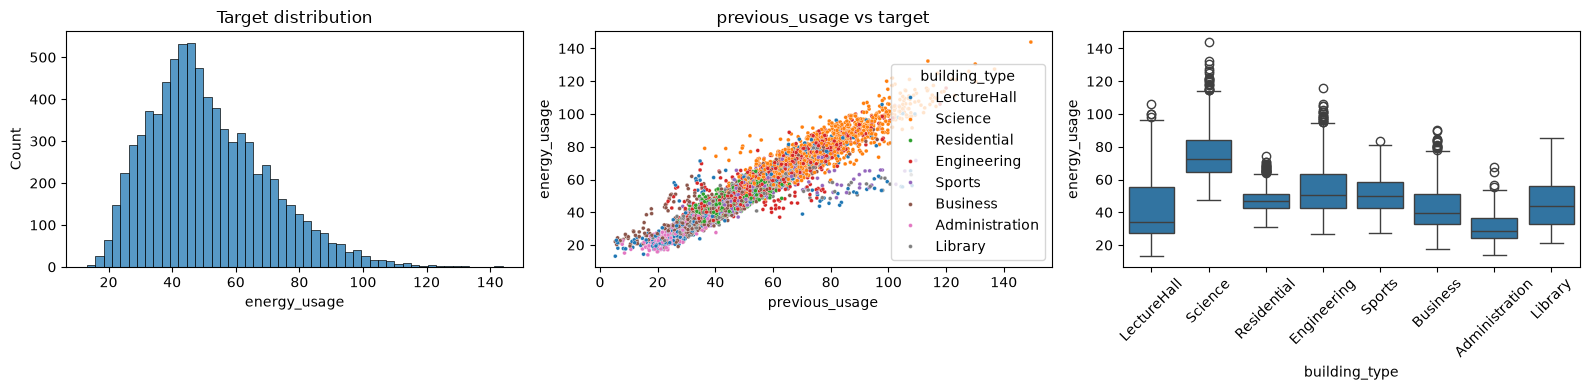

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(train_df[TARGET], bins=50, ax=ax[0]).set_title("Target distribution")
sns.scatterplot(data=train_df, x="previous_usage", y=TARGET, hue="building_type", s=8, ax=ax[1]).set_title("previous_usage vs target")
sns.boxplot(data=train_df, x="building_type", y=TARGET, ax=ax[2]); ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

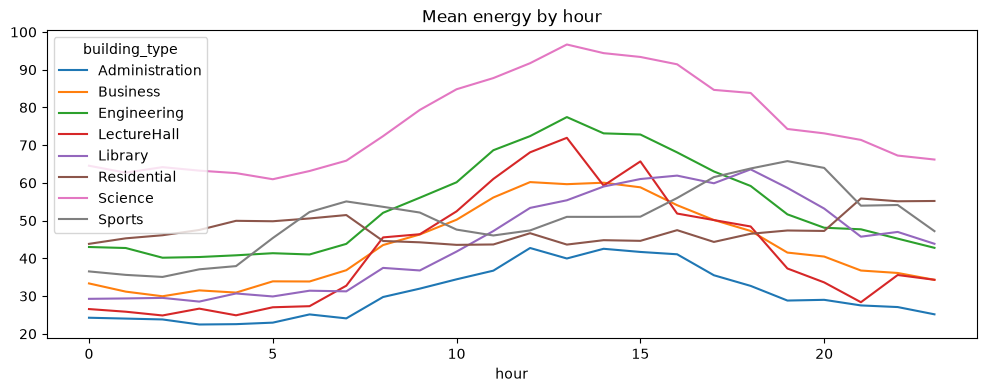

humidity         -0.249620
month            -0.064579
hour              0.236417
occupancy         0.411708
temperature       0.489184
previous_usage    0.945376
energy_usage      1.000000
Name: energy_usage, dtype: float64

In [5]:
# Daily load profile differs by building type -> building x hour interaction matters
train_df.pivot_table(index="hour", columns="building_type", values=TARGET).plot(figsize=(12, 4), title="Mean energy by hour")
plt.show()
train_df.select_dtypes("number").corr()[TARGET].sort_values()

**Key findings (fill in / refine):**
- `previous_usage` is by far the strongest predictor (r ≈ 0.95); a naive "predict previous_usage" baseline already scores RMSE ≈ 6.7.
- Each building has its own level and daily shape (Science highest, Admin lowest; Sports peaks in the evening).
- Temperature (+) and occupancy (+) matter; humidity weakly (−).
- ~1.5% missing in each of temperature / humidity / occupancy / previous_usage (train and test). Rows missing `previous_usage` are the hardest.
- Rows have no timestamp/year and IDs are shuffled, so we cannot build true lag features; treat as tabular regression.

## 3–4. Cleaning & feature engineering
`make_features` must be **pure** (no statistics learned from train) so it can be copied verbatim into the inference notebook. All learned steps (imputation, scaling) live inside the sklearn pipeline saved in `model.pkl`.

In [6]:
BUILDINGS = ["ADM_A", "BUS_A", "BUS_B", "ENG_A", "ENG_B", "LEC_A",
             "LIB_A", "RES_A", "RES_B", "SCI_A", "SCI_B", "SPT_A"]
DOW = {"Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3,
       "Friday": 4, "Saturday": 5, "Sunday": 6}
NUMS = ["temperature", "humidity", "occupancy", "previous_usage"]

def make_features(df):
    df = df.copy()
    X = pd.DataFrame(index=df.index)
    X["hour"] = df["hour"]
    X["month"] = df["month"]
    X["dow"] = df["day_of_week"].map(DOW)
    X["weekend"] = (X["dow"] >= 5).astype(int)
    X["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    X["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    X["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    for c in NUMS:
        X[c] = df[c]
        X[c + "_missing"] = df[c].isna().astype(int)
    X["building_code"] = df["building_id"].map({b: i for i, b in enumerate(BUILDINGS)})
    # Building one-hots and building-specific slopes / daily profiles (lets a linear model fit each building separately)
    for b in BUILDINGS:
        is_b = (df["building_id"] == b).astype(float)
        X[f"b_{b}"] = is_b
        X[f"b_{b}_weekend"] = is_b * X["weekend"]
        X[f"b_{b}_occ"] = is_b * df["occupancy"]      # NaN kept -> imputed in pipeline
        X[f"b_{b}_temp"] = is_b * df["temperature"]
        X[f"b_{b}_prev"] = is_b * df["previous_usage"]
        for h in range(24):
            X[f"b_{b}_h{h}"] = is_b * (df["hour"] == h)
    return X

X_train = make_features(train_df)
y_train = train_df[TARGET]
feature_names = list(X_train.columns)
print(X_train.shape)

(8000, 365)


## 5. Baseline + evaluation helper
All scores use 5-fold CV on the training set (out-of-fold predictions).

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

def evaluate(name, y_true, y_pred):
    results[name] = {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                     "MAE": mean_absolute_error(y_true, y_pred),
                     "R2": r2_score(y_true, y_pred)}
    print(f"{name:<22} RMSE={results[name]['RMSE']:.3f}  MAE={results[name]['MAE']:.3f}  R2={results[name]['R2']:.4f}")

# Naive persistence baseline: energy now = previous usage
naive = train_df["previous_usage"].fillna(y_train.mean())
evaluate("Naive (prev usage)", y_train, naive)

Naive (prev usage)     RMSE=6.716  MAE=4.465  R2=0.8675


## 6. Train & compare models

In [8]:
def ridge_model():
    return make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                         RidgeCV(alphas=np.logspace(-2, 3, 30)))

def hgb_model():
    # Native NaN handling; uses only the compact features
    return HistGradientBoostingRegressor(max_iter=1500, learning_rate=0.03, max_leaf_nodes=15,
                                         min_samples_leaf=20, l2_regularization=1.0,
                                         early_stopping=True, random_state=SEED)

compact = ["hour", "month", "dow", "weekend", "hour_sin", "hour_cos", "building_code"] + NUMS + [c + "_missing" for c in NUMS]

models = {
    "Ridge (interactions)": (ridge_model(), feature_names),
    "RandomForest": (make_pipeline(SimpleImputer(strategy="median"),
                                   RandomForestRegressor(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=SEED)), compact),
    "HistGradientBoosting": (hgb_model(), compact),
}
oof = {}
for name, (m, cols) in models.items():
    oof[name] = cross_val_predict(m, X_train[cols], y_train, cv=kf)
    evaluate(name, y_train, oof[name])

evaluate("Blend Ridge+HGB", y_train, (oof["Ridge (interactions)"] + oof["HistGradientBoosting"]) / 2)

Ridge (interactions)   RMSE=3.359  MAE=2.586  R2=0.9668


RandomForest           RMSE=4.206  MAE=3.166  R2=0.9480


HistGradientBoosting   RMSE=3.560  MAE=2.771  R2=0.9628
Blend Ridge+HGB        RMSE=3.298  MAE=2.569  R2=0.9680


In [9]:
pd.DataFrame(results).T.sort_values("RMSE")

,RMSE,MAE,R2
Blend Ridge+HGB,3.297745,2.569470,0.968045
Ridge (interactions),3.359078,2.586041,0.966845
HistGradientBoosting,3.559938,2.771226,0.962761
RandomForest,4.205912,3.165646,0.948021
Naive (prev usage),6.716315,4.464798,0.867453


### Why this model? (explain for the 40% understanding score)
- The data looks close to **additive**: building-specific level + building-specific daily profile + linear effects of previous usage, temperature and occupancy. A regularised linear model with explicit building interactions captures that structure directly, extrapolates sensibly to unseen/edge values (important for the private test set), and is interpretable.
- Gradient boosting captures remaining non-linearities and handles missing values natively.
- Averaging two models with different biases lowers variance → best CV RMSE.
- **Assumptions:** rows are independent (no time ordering available), relationships are stable across months, the test buildings are the same 12 as train, residuals are roughly symmetric (checked below).

## 7. Evaluation & diagnostics

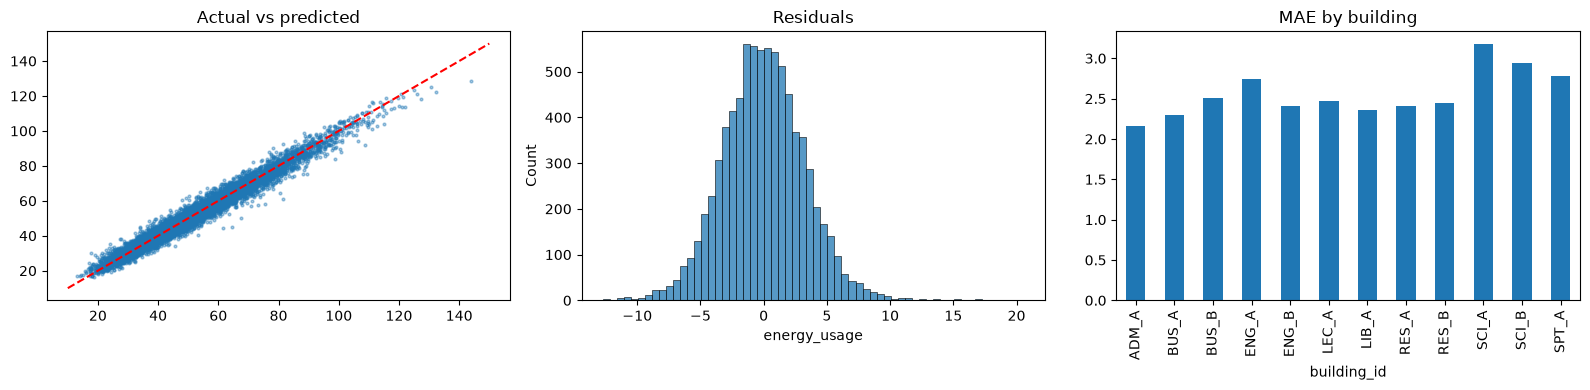

RMSE when previous_usage present: 3.2268581401983116
RMSE when previous_usage missing: 6.547483906665411


In [10]:
best_oof = (oof["Ridge (interactions)"] + oof["HistGradientBoosting"]) / 2
res = y_train - best_oof
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].scatter(y_train, best_oof, s=4, alpha=.4); ax[0].plot([10, 150], [10, 150], "r--"); ax[0].set_title("Actual vs predicted")
sns.histplot(res, bins=60, ax=ax[1]).set_title("Residuals")
train_df.assign(abs_err=res.abs()).groupby("building_id")["abs_err"].mean().plot.bar(ax=ax[2], title="MAE by building")
plt.tight_layout(); plt.show()

miss = train_df["previous_usage"].isna()
print("RMSE when previous_usage present:", np.sqrt(mean_squared_error(y_train[~miss], best_oof[~miss])))
print("RMSE when previous_usage missing:", np.sqrt(mean_squared_error(y_train[miss], best_oof[miss])))

## 8. Fit final model on all training data & save `model.pkl`
`VotingRegressor` keeps the blend as a single sklearn object. A `ColumnTransformer` gives each sub-model its own columns.

In [11]:
from sklearn.compose import ColumnTransformer

hgb_branch = make_pipeline(ColumnTransformer([("keep", "passthrough", compact)]), hgb_model())
final_model = VotingRegressor([("ridge", ridge_model()), ("hgb", hgb_branch)])
final_model.fit(X_train[feature_names], y_train)

joblib.dump((final_model, feature_names), "model.pkl")
print("Saved model.pkl")

Saved model.pkl


## 9. Inference (mirrors the separate submission notebook)

In [12]:
model, features = joblib.load("model.pkl")
input_path = os.environ.get("DATATHON_INPUT_PATH", TEST_PATH)
test_df = pd.read_csv(input_path)
X_test = make_features(test_df)
preds = model.predict(X_test[features])

out = pd.DataFrame({"prediction": preds})
out.to_csv("TEAMNAME_Datathon 2026_Track 1_Prediction.csv", index=False)
print(out.shape, out["prediction"].describe())

(3000, 1) count    3000.000000
mean       54.540340
std        19.635128
min        15.198894
25%        40.775249
50%        53.188459
75%        66.790714
max       126.568434
Name: prediction, dtype: float64


## 10. Limitations & next steps
- No timestamps → no real lag/rolling features; `previous_usage` is the only history.
- Missing `previous_usage` rows have ~2× error; could impute it with a sub-model.
- Try: tuned LightGBM/CatBoost, Optuna, quantile check on private-test edge cases (extreme temperature/occupancy).